In [1]:
from rtnls_oct.eyened.dataloading import load_segmentation_from_orm, load_oct_by_id, load_model_segmentation_with_oct_by_id
from eyened_orm import Database

database = Database()


## Load by segmentation ID's

In [42]:
with database.get_session() as session:
    segmentation, oct_volume = load_model_segmentation_with_oct_by_id(session, 1477183)
    segmentation2, oct_volume2 = load_model_segmentation_with_oct_by_id(session, 1477184)

Subfeatures: {0: 'background', 1: 'Retinal Nerve Fiber Layer (RNFL)', 2: 'Ganglion cell layer (GCL)', 3: 'Inner plexiform layer (IPL)', 4: 'Inner nuclear layer (INL)', 5: 'Outer plexiform layer (OPL)', 6: 'Outer nuclear layer (ONL)', 7: 'External limiting membrane (ELM)', 8: 'Myoid zone (MZ)', 9: 'Ellipsoid zone (EZ)', 10: 'Outer Segments (OS)', 11: 'Inter Digitation Zone (IDZ)', 12: 'Retinal pigment epithelium (RPE)', 13: 'Choroid', 14: 'Other'}
Subfeatures: {0: 'background', 1: 'Retinal Nerve Fiber Layer (RNFL)', 2: 'Ganglion cell layer (GCL)', 3: 'Inner plexiform layer (IPL)', 4: 'Inner nuclear layer (INL)', 5: 'Outer plexiform layer (OPL)', 6: 'Outer nuclear layer (ONL)', 7: 'External limiting membrane (ELM)', 8: 'Myoid zone (MZ)', 9: 'Ellipsoid zone (EZ)', 10: 'Outer Segments (OS)', 11: 'Inter Digitation Zone (IDZ)', 12: 'Retinal pigment epithelium (RPE)', 13: 'Choroid', 14: 'Other'}


## Load by ImageInstance ID's

In [ ]:
from eyened_orm import ModelSegmentation, SegmentationModel

id1 = 2759251
id2 = 2759250

with database.get_session() as session:
    oct_volume = load_oct_by_id(session, id1)
    oct_volume2 = load_oct_by_id(session, id2)
    segmentationmodel = SegmentationModel.by_name(session,'nnUNet macular layers v3')
    modelsegmentation = session.query(ModelSegmentation).filter(ModelSegmentation.ImageInstanceID==id1, ModelSegmentation.Model==segmentationmodel).first()
    modelsegmentation2 = session.query(ModelSegmentation).filter(ModelSegmentation.ImageInstanceID==id2, ModelSegmentation.Model==segmentationmodel).first()
    segmentation = load_segmentation_from_orm(modelsegmentation)
    segmentation2 = load_segmentation_from_orm(modelsegmentation2)


In [36]:
segmentation.LABELS

{'background': 0,
 'Retinal Nerve Fiber Layer (RNFL)': 1,
 'Ganglion cell layer (GCL)': 2,
 'Inner plexiform layer (IPL)': 3,
 'Inner nuclear layer (INL)': 4,
 'Outer plexiform layer (OPL)': 5,
 'Outer nuclear layer (ONL)': 6,
 'External limiting membrane (ELM)': 7,
 'Myoid zone (MZ)': 8,
 'Ellipsoid zone (EZ)': 9,
 'Outer Segments (OS)': 10,
 'Inter Digitation Zone (IDZ)': 11,
 'Retinal pigment epithelium (RPE)': 12,
 'Choroid': 13,
 'Other': 14}

/home/kvangarderen/rtnls-env/lib/python3.11/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


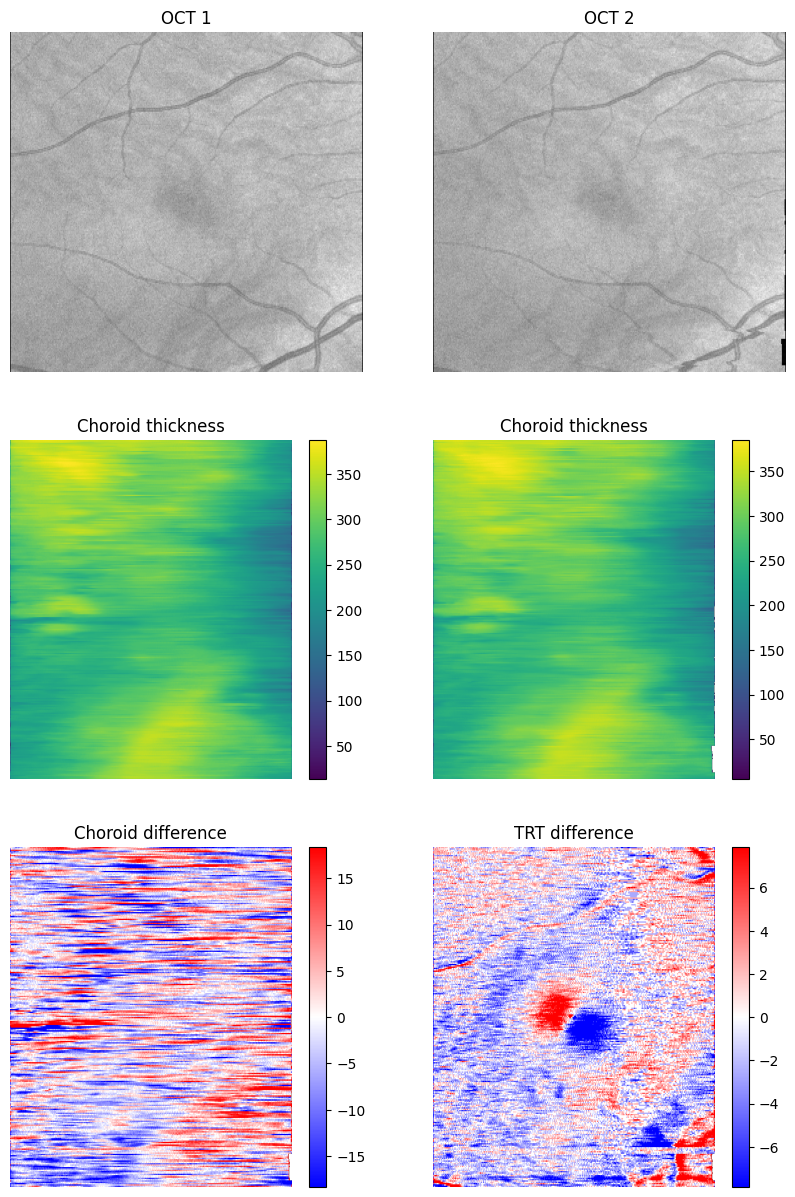

In [51]:
import matplotlib.pyplot as plt
import numpy as np

thickness_map_1 =segmentation.get_thickness_map(['Choroid']) * oct_volume.res_height_mm * 1000
thickness_map_2 =segmentation2.get_thickness_map(['Choroid']) * oct_volume2.res_height_mm * 1000
trt_map = segmentation.get_thickness_map(list(segmentation.LABELS.keys())[1:12]) * oct_volume.res_height_mm * 1000
trt_map2 = segmentation2.get_thickness_map(list(segmentation2.LABELS.keys())[1:12]) * oct_volume2.res_height_mm * 1000

fig, ax = plt.subplots(3,2, figsize=(10,15))
ax[0,0].imshow(oct_volume.enface_projection(), cmap='gray', aspect='auto')
ax[0,1].imshow(oct_volume2.enface_projection(), cmap='gray', aspect='auto')
ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,0].set_title('OCT 1')
ax[0,1].set_title('OCT 2')
cb = ax[1,0].imshow(thickness_map_1, aspect='auto')
plt.colorbar(cb, ax=ax[1,0])
ax[1,0].axis('off')
ax[1,0].set_title('Choroid thickness')
cb = ax[1,1].imshow(thickness_map_2, aspect='auto')
plt.colorbar(cb, ax=ax[1,1])
ax[1,1].axis('off')
ax[1,1].set_title('Choroid thickness')
maxval = np.quantile(np.abs(thickness_map_1 - thickness_map_2), 0.95)
cb = ax[2,0].imshow(thickness_map_1 - thickness_map_2, aspect='auto', cmap='bwr', vmin=-maxval, vmax=maxval)
ax[2,0].axis('off')
ax[2,0].set_title('Choroid difference')
plt.colorbar(cb, ax=ax[2,0])
maxval = np.quantile(np.abs(trt_map - trt_map2), 0.95)
cb = ax[2,1].imshow(trt_map - trt_map2, aspect='auto', cmap='bwr', vmin=-maxval, vmax=maxval)
ax[2,1].axis('off')
ax[2,1].set_title('TRT difference')
plt.colorbar(cb, ax=ax[2,1])
plt.show()